In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from numba import jit, njit
from scipy.stats import  t
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [3]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx # Number of trajectories
        self.Nt = Nt # Number of discretization steps
        self.init_state = init_state

    # Wiener Process by default
    # use @staticmethod for numba compatibility with @njit
    @staticmethod
    @njit
    def bxt(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return 1

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return 0

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return 0

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return 0

    def DefaultInitState(self):
        return np.zeros(self.Nx)

    def EulerSolution(self, dwt = None):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if dwt is None:
            dwt = np.random.normal(0, 1, size = (self.Nt, self.Nx)) * np.sqrt(dt)

        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1], t_data[i - 1], self.params) * dt +\
                        self.sigmaxt(x_data[i - 1], t_data[i - 1], self.params) * dwt[i - 1]
        return t_data, x_data

    @staticmethod
    @njit
    def EulerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        xs = x0 + bxt(x0, t0, params) * (t - t0)
        sigma2 = sigmaxt(x0, t0, params)**2 * (t - t0)

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def OzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        K = 1 / (t - t0) * np.log(1 + bxt(x0, t0, params) / (x0 * bxt_x(x0, t0, params)) * (np.exp(bxt_x(x0, t0, params) * (t - t0)) - 1))
        E = x0 + bxt(x0, t0, params) / bxt_x(x0, t0, params) * (np.exp(bxt_x(x0, t0, params) * (t - t0)) - 1)
        V = sigmaxt(x0, t0, params)**2 / (2 * K) * (np.exp(2 * K * (t - t0)) - 1)

        xs = E
        sigma2 = V

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def ShojiOzakiDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        L = bxt_x(x0, t0, params)

        #safe division
        if L == 0:
            L = L + 0.001

        M = sigmaxt(x0, t0, params)**2 / 2 * bxt_xx(x0, t0, params) + bxt_t(x0, t0, params)

        A = 1 + bxt(x0, t0, params) / (x0 * L) * (np.exp(L * (t - t0)) - 1) + M / (x0 * L**2) * \
            (np.exp(L * (t - t0)) - 1 - L * (t - t0))
        B = sigmaxt(x0, t0, params)**2 * 1/(2 * L) * (np.exp(2 * L * (t - t0)) - 1)

        xs = A * x0
        sigma2 = B

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def KesslerDensity(x, t, x0, t0, params, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        E = x0 + bxt(x0, t0, params) * (t - t0) + (bxt(x0, t0, params) * bxt_x(x0, t0, params) + 1/2 * \
            sigmaxt(x0, t0, params)**2 * bxt_xx(x0, t0, params)) * 1/2 * (t - t0)**2
        V = x0**2 + (2 * bxt(x0, t0, params) * x0 + sigmaxt(x0, t0, params)**2 ) * (t - t0)\
            + (2 * bxt(x0, t0, params) * (bxt_x(x0, t0, params) * x0 + bxt(x0, t0, params) + \
                sigmaxt(x0, t0, params) * sigmaxt_x(x0, t0, params))\
            + sigmaxt(x0, t0, params)**2 * (bxt_xx(x0, t0, params) * x0 + 2 * bxt_x(x0, t0, params) +\
                sigmaxt_x(x0, t0, params)**2 + sigmaxt(x0, t0, params) * sigmaxt_xx(x0, t0, params))) * (t - t0)**2 / 2 - E**2

        xs = E

        #safe division
        if V == 0:
            V = V + 0.001

        sigma2 = V

        return -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

    @staticmethod
    @njit
    def MLogLik(params, t_data, x_data, density, bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t):
        Nt = len(x_data)
        Nx = len(x_data[0])
        log_data = np.zeros(Nx)
        for k in range(0, Nx):
            m_log_lik = 0
            for j in range(1, Nt):
                m_log_lik += density(x_data[j][k], t_data[j], x_data[j - 1][k], t_data[j - 1], params,
                                     bxt, bxt_x, bxt_xx, sigmaxt, sigmaxt_x, sigmaxt_xx, bxt_t)
            log_data[k] = m_log_lik

        res = -np.mean(log_data)
        return res

    def EulerEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.EulerDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def OzakiEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.OzakiDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def ShojiOzakiEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.ShojiOzakiDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result

    def KesslerEstimation(self, t_data, x_data):
        x0 = np.ones(len(self.params))
        accuracy = 1e-8

        min_result = minimize(self.MLogLik,
                              x0 = x0,
                              args=(t_data, x_data, self.KesslerDensity,
                              self.bxt, self.bxt_x, self.bxt_xx, self.sigmaxt, self.sigmaxt_x, self.sigmaxt_xx,
                              self.bxt_t),
                              method = 'L-BFGS-B',
                              options={'ftol': accuracy, 'eps': accuracy})
        return min_result


class OUprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta, mu, sigma]

    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * (params[1] - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0]

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

class CKLSprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] + params[1] * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * x**params[3]

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[2] * params[3] * x**(params[3] - 1)

    @staticmethod
    @njit
    def sigmaxt_xx(x, t, params):
        return params[2] * params[3] * (params[3] - 1) * x**(params[3] - 2)

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

class Task5process(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * t * x

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[1] * x

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return params[0] * t

    @staticmethod
    @njit
    def sigmaxt_x(x, t, params):
        return params[1]

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return params[0] * x

    def DefaultInitState(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

class HullWhiteprocess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

    # params = [theta1, theta2, theta3]
    @staticmethod
    @njit
    def bxt(x, t, params):
        return params[0] * t * (params[1] * np.sqrt(t) - x)

    @staticmethod
    @njit
    def sigmaxt(x, t, params):
        return params[2] * t

    @staticmethod
    @njit
    def bxt_x(x, t, params):
        return -params[0] * t

    @staticmethod
    @njit
    def bxt_t(x, t, params):
        return params[0] * params[1] * 3/2 * np.sqrt(t)

    def DefaultInitState(self):
        return self.params[1] * np.ones(self.Nx)

Task 1. Evaluate the conditional density of the Ornstein-Uhlenbeck process
$$dX_t = (3-X_t)dt+2dW_t, \quad X_0=1, \quad %\theta=(1, 3, 2), \quad
N=100000,
\quad \Delta=1$$ and calculate the
maximum likelihood estimation.  

In [4]:
Nx = 100000
Nt = 300

T = 1

params_OU = np.array([3, 1, 2])

x0 = 1
init_state = x0 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.EulerSolution()

In [5]:
OUp.EulerEstimation(t_data, x_data_OU)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.87118815136756
        x: [ 3.006e+00  9.994e-01  2.000e+00]
      nit: 14
      jac: [ 4.377e-04  1.421e-04 -4.491e-03]
     nfev: 64
     njev: 16
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [6]:
OUp.ShojiOzakiEstimation(t_data, x_data_OU)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.8711879990807
        x: [ 3.022e+00  9.998e-01  2.011e+00]
      nit: 13
      jac: [ 1.251e-04  3.780e-04 -4.832e-04]
     nfev: 60
     njev: 15
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [7]:
OUp.KesslerEstimation(t_data, x_data_OU)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -221.8711851999652
        x: [ 3.021e+00  9.994e-01  2.011e+00]
      nit: 15
      jac: [ 1.421e-04 -5.400e-05 -1.592e-03]
     nfev: 76
     njev: 19
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

Task. Find the maximum likelihood estimators  numerically
 for Ornstein-Uhlenbeck process
 $$
 dX_t = -\theta_2X_tdt + \theta_3dW_t, \quad \theta=(0, 3, 2), \quad
N=1000, \quad \Delta=1
$$
and compare with explicit estimations

$$
\hat{\theta}_{2,n} = -\frac{1}{\Delta}\log \left(\frac{\sum_{i=1}^n X_{i-1}X_i} {\sum_{i=1}^n X^2_{i-1}}\right),
$$
$$
\hat{\theta}_{3,n} = \sqrt{\frac{2\hat{\theta}_{2,n}}
{n(1 - e^{-2\Delta  \hat{\theta}_{2,n}})}
\sum_{i=1}^n (X_i- X_{i-1} e^{-\Delta \hat{\theta}_{2, n}})^2}.
$$

In [8]:
# your code

Task 3. Consider  the Chan-Karolyi-Longstaff-Sanders (CKLS) model
$$
 dX_{t} = (\theta_{1}+\theta_{2} X_{t}) dt + \theta_{3} X_{t}^{\theta_{4}} dW_{t},\qquad X_{0}=2
$$
with $\theta_{1}=1$, $\theta_{2}=2$, $\theta_{3}=0.5$, $\theta_{4}=0.3$.

Use the Euler method and
* generate the sample data $X_{t_i}$ with time step $\Delta t =10^{-4}$,  
* estimate drift and diffusion coefficients,
* compute confidence intervals for all parameters in a fitted SDE.  


In [9]:
Nx = 1
Nt = 10000

T = 1

params_CKLS = np.array([1, 2, 0.5, 0.3])

x0 = 2
init_state = x0 * np.ones(Nx)

CKLSp = CKLSprocess(params_CKLS, T, Nx, Nt, init_state)

t_data, x_data_CKLS = CKLSp.EulerSolution()

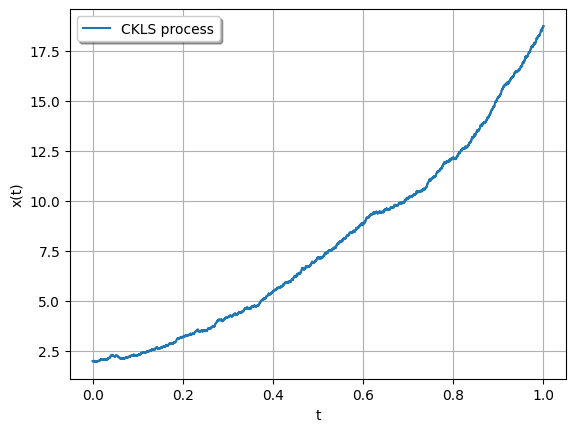

In [10]:
plt.plot(t_data, x_data_CKLS[:,0], label = 'CKLS process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [11]:
CKLSp.EulerEstimation(t_data, x_data_CKLS)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -33238.19671136386
        x: [ 1.114e+00  1.983e+00  5.005e-01  2.984e-01]
      nit: 18
      jac: [-3.347e-01  2.110e-02 -3.638e-02  2.183e-02]
     nfev: 115
     njev: 23
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>

In [12]:
#Confidence intervals
n = 50
result = np.zeros((n, 4))
for k in range(0, n):
    t_data, x_data_CKLS = CKLSp.EulerSolution()
    result[k] = CKLSp.EulerEstimation(t_data, x_data_CKLS).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 4):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = 1.051130157261733 +- 0.2200794860921224 with 95.0% prob
theta1 = 1.9949562943790335 +- 0.047473845555296636 with 95.0% prob
theta2 = 0.4986977643993555 +- 0.0030321087616001735 with 95.0% prob
theta3 = 0.30116823006861543 +- 0.0032086033333344646 with 95.0% prob


Task 4. Consider the Vasicek model
$$
dX_{t} = \theta_{1} (\theta_{2}- X_{t}) dt + \theta_{3} dW_{t},\qquad X_{0}=5
$$
with $\theta_{1}=3$, $\theta_{2}=2$ and $\theta_{3}=0.5$.

Use the Ozaki method and
*   generate the sample data $X_{t_i}$, time step $\Delta t =10^{-2}$,
*   estimate drift and diffusion coefficients,
*   compute confidence intervals for all parameters in a fitted SDE.

In [13]:
Nx = 1
Nt = 100

T = 1

params_OU = np.array([3, 2, 0.5])

x0 = 5
init_state = x0 * np.ones(Nx)

OUp = OUprocess(params_OU, T, Nx, Nt, init_state)

t_data, x_data_OU = OUp.EulerSolution()

In [14]:
OUp.OzakiEstimation(t_data, x_data_OU)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -161.33773959142698
        x: [ 2.889e+00  1.962e+00  4.839e-01]
      nit: 21
      jac: [-4.547e-05  1.194e-04  1.336e-04]
     nfev: 108
     njev: 27
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

In [15]:
#Confidence intervals
n = 50
result = np.zeros((n, 3))
for k in range(0, n):
    t_data, x_data_OU = OUp.EulerSolution()
    result[k] = OUp.OzakiEstimation(t_data, x_data_OU).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 3):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = 3.3536188514215333 +- 0.21690125573786517 with 95.0% prob
theta1 = 2.007622804825922 +- 0.1113545392020396 with 95.0% prob
theta2 = 0.4560665728289809 +- 0.05578204697142602 with 95.0% prob


Task 5. Consider the model
$$
  dX_{t} = a(t)X_{t} dt + \theta_{2}X_{t} dW_{t},\qquad X_{0}=10
$$
with $a(t) = \theta_{1}t$, $\theta_{1}=-2$, $\theta_{2}=0.2$.

Use the Shoji-Ozaki method and:
* generate the sample data $X_{t_i}$ time step $\Delta t =10^{-3}$,  
* estimate drift and diffusion coefficients,
* compute confidence intervals for all parameters in a fitted SDE.

In [16]:
Nx = 1
Nt = 1000

T = 1

params_T5 = np.array([-2, 0.2])

x0 = 5
init_state = x0 * np.ones(Nx)

T5p = Task5process(params_T5, T, Nx, Nt, init_state)

t_data, x_data_T5 = T5p.EulerSolution()

In [17]:
T5p.ShojiOzakiEstimation(t_data, x_data_T5)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -2243.8522764252684
        x: [-2.378e+00  1.981e-01]
      nit: 16
      jac: [ 7.685e-03 -1.066e-01]
     nfev: 66
     njev: 22
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

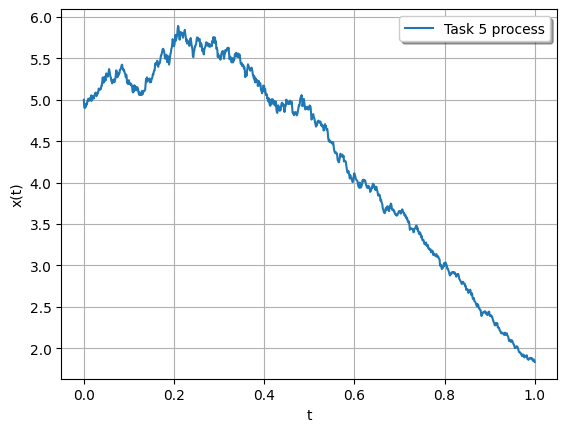

In [18]:
plt.plot(t_data, x_data_T5[:,0], label = 'Task 5 process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [19]:
#Confidence intervals
n = 50
result = np.zeros((n, 2))
for k in range(0, n):
    t_data, x_data_T5 = T5p.EulerSolution()
    result[k] = T5p.ShojiOzakiEstimation(t_data, x_data_T5).x


alpha = 0.05
q = t.ppf(1-alpha/2, n - 1)
for i in range(0, 2):
    m = np.mean(result[:,i])
    v = np.std(result[:,i], ddof=1)
    print(f"theta{i} = {m} +- {v * q / np.sqrt(n)} with {100 - alpha * 100}% prob")

theta0 = -1.8793143102410044 +- 0.1445633848277184 with 95.0% prob
theta1 = 0.20053353630918264 +- 0.0012397692368504398 with 95.0% prob


Task 6. Consider the Hull-White (extended Vasicek) model
$$
  dX_{t} = a(t)(b(t)-X_{t}) dt + \sigma(t) dW_{t},\qquad X_{0}=2
$$
with $a(t) = \theta_{1}t$, $b(t)=\theta_{2}\sqrt{t}$, the volatility depends on time $\sigma(t)=\theta_{3}t$.

Generate sample data of $X_t$ with time step $\Delta t =10^{-3}$ and $\theta_{1}=3$, $\theta_{2}=1$ and $\theta_{3}=0.3$, then
use the Kessler method and:
*   estimate drift and diffusion coefficients,
*   compute confidence intervals for all parameters in a fitted SDE.

In [20]:
Nx = 1
Nt = 100

T = 1

params_HW = np.array([3, 1, 0.3])

x0 = 2
init_state = x0 * np.ones(Nx)

HWp = HullWhiteprocess(params_HW, T, Nx, Nt, init_state)

t_data, x_data_HW = HWp.EulerSolution()

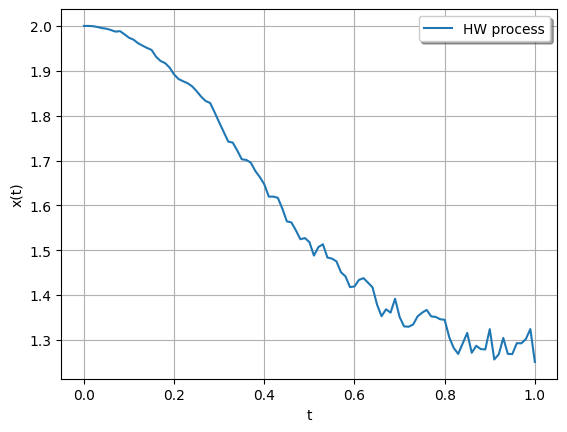

In [21]:
plt.plot(t_data, x_data_HW[:,0], label = 'HW process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

In [22]:
HWp.KesslerEstimation(t_data, x_data_HW)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -311.7580820285699
        x: [ 3.712e+00  1.294e+00  2.846e-01]
      nit: 17
      jac: [ 7.377e-02  4.041e-01  4.318e-01]
     nfev: 160
     njev: 40
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>

Task. Take a process from previous tasks and approximation method, find the solution, compute confidence intervals, and compare results with baseline.

Plot the graph and table.

Задания по вариантам
1. Байков Илья Павлович OU + Kessler
1. Гонгапшев Астемир Султанович CKLS + Shoji-Ozaki
1. Кудинкина Екатерина Андреевна CKLS + Kessler
1. Кулига Андрей Владимирович Vasicek + Euler
1. Мартыненко Александр Станиславович Vasicek + Shoji-Ozaki
1. Мироманов Даниил Борисович Vasicek + Kessler
1. Паршаков Никита Сергеевич extended Vasicek + Euler
1. Петренко Влада Витальевна extended Vasicek + Ozaki
1. Тумачев Серафим Дмитриевич extended Vasicek + Shoji-Ozaki
1. Хубиев Касымхан Юсуфович model 5 + Euler
1. Ширяева Софья Игоревна model 5 + Ozaki
1. Якунин Сергей Александрович model 5 + Kessler
1. Трофимов Яков Георгиевич CKLS + Ozaki


In [23]:
# your code

Задание 1. Сравнительный анализ точного и численного MLE

1. Для процесса Орнштейна-Уленбека (модель Вазичека) сгенерируйте траекторию процесса, параметры $\theta = (\theta_1, \theta_2, \theta_3)$ укажите самостоятельно.

2. Вычислите оценки параметров двумя способами: аналитически и численно минимизируя функцию отрицательного логарифма правдоподобия (`MLogLik`) с использованием схемы Эйлера.

3. Оцените абсолютную относительную ошибку численного метода по сравнению с аналитическим решением.

4. Сделайте выводы.


,parameter,true,exact_MLE,numeric_Euler_MLE,abs_rel_error_numeric_vs_exact
0,theta1/kappa,1.7,1.696897,1.626879,0.041262
1,theta2/alpha,2.5,2.383951,2.383955,0.000002
2,theta3/sigma,0.8,0.801381,0.768555,0.040962


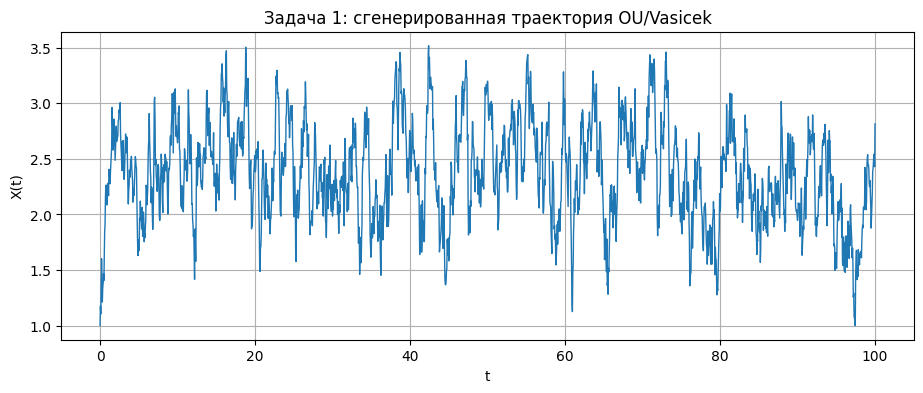

Вывод: аналитическое MLE использует точную переходную плотность OU, а численное Euler-MLE —
гауссовскую аппроксимацию Эйлера. При малом шаге Delta оценки близки; расхождение показывает
ошибку дискретизационной аппроксимации Euler likelihood относительно точного MLE.


In [1]:


import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

np.random.seed(42)


def simulate_ou_exact(theta, T, Nt, x0, rng=None):
    """Точная дискретная симуляция OU: dX = kappa*(alpha-X)dt + sigma dW."""
    if rng is None:
        rng = np.random.default_rng()
    kappa, alpha, sigma = map(float, theta)
    dt = T / Nt
    t = np.linspace(0, T, Nt + 1)
    x = np.zeros(Nt + 1)
    x[0] = x0
    phi = np.exp(-kappa * dt)
    sd = sigma * np.sqrt((1 - np.exp(-2 * kappa * dt)) / (2 * kappa))
    for i in range(1, Nt + 1):
        x[i] = alpha + (x[i - 1] - alpha) * phi + sd * rng.normal()
    return t, x


def ou_exact_mle(x, dt):
    """Аналитический MLE для OU/Vasicek по AR(1)-представлению."""
    x_prev = np.asarray(x[:-1], dtype=float)
    x_next = np.asarray(x[1:], dtype=float)
    n = len(x_next)

    s_xx = np.sum(x_prev ** 2)
    s_xy = np.sum(x_prev * x_next)
    mean_prev = np.mean(x_prev)
    mean_next = np.mean(x_next)
    denom = s_xx / n - mean_prev ** 2
    beta1 = (s_xy / n - mean_prev * mean_next) / denom
    beta1 = np.clip(beta1, 1e-8, 1 - 1e-8)
    beta2 = np.mean(x_next - beta1 * x_prev) / (1 - beta1)
    resid = x_next - beta1 * x_prev - beta2 * (1 - beta1)
    beta3 = np.mean(resid ** 2)

    kappa_hat = -np.log(beta1) / dt
    alpha_hat = beta2
    sigma_hat = np.sqrt(2 * kappa_hat * beta3 / (1 - beta1 ** 2))
    return np.array([kappa_hat, alpha_hat, sigma_hat])


def ou_euler_negloglik(theta, x, dt):
    """Отрицательное лог-правдоподобие Эйлера для OU."""
    kappa, alpha, sigma = theta
    if kappa <= 0 or sigma <= 0 or not np.isfinite(theta).all():
        return 1e100
    x_prev = x[:-1]
    x_next = x[1:]
    mean = x_prev + kappa * (alpha - x_prev) * dt
    var = sigma ** 2 * dt
    return 0.5 * np.sum(np.log(2 * np.pi * var) + (x_next - mean) ** 2 / var)


def ou_euler_mle_numeric(x, dt, start=None):
    """Численное MLE: минимизация Euler negative log-likelihood."""
    if start is None:
        start = np.array([1.0, np.mean(x), np.std(np.diff(x)) / np.sqrt(dt)])
        start[2] = max(start[2], 1e-3)
    res = minimize(
        ou_euler_negloglik,
        x0=start,
        args=(x, dt),
        method='L-BFGS-B',
        bounds=[(1e-6, 50), (-50, 50), (1e-6, 20)],
    )
    return res

# Параметры рандомно
theta_true = np.array([1.7, 2.5, 0.8])  # kappa, alpha, sigma
T = 100.0
Delta = 0.05
Nt = int(T / Delta)
x0 = 1.0
rng = np.random.default_rng(42)

t_data, x_ou = simulate_ou_exact(theta_true, T, Nt, x0, rng=rng)

exact_hat = ou_exact_mle(x_ou, Delta)
euler_res = ou_euler_mle_numeric(x_ou, Delta, start=exact_hat)
euler_hat = euler_res.x

summary_task1 = pd.DataFrame({
    'parameter': ['theta1/kappa', 'theta2/alpha', 'theta3/sigma'],
    'true': theta_true,
    'exact_MLE': exact_hat,
    'numeric_Euler_MLE': euler_hat,
    'abs_rel_error_numeric_vs_exact': np.abs(euler_hat - exact_hat) / np.maximum(np.abs(exact_hat), 1e-12),
})

display(summary_task1)

plt.figure(figsize=(11, 4))
plt.plot(t_data, x_ou, linewidth=1)
plt.title('Задача 1: сгенерированная траектория OU/Vasicek')
plt.xlabel('t')
plt.ylabel('X(t)')
plt.grid(True)
plt.show()

print('Вывод: аналитическое MLE использует точную переходную плотность OU, а численное Euler-MLE —')
print('гауссовскую аппроксимацию Эйлера. При малом шаге Delta оценки близки; расхождение показывает')
print('ошибку дискретизационной аппроксимации Euler likelihood относительно точного MLE.')

Задача 2. Оценивание параметров в семействе моделей CKLS

1. Используя модель Чана-Карольи-Лонгстаффа-Сандерса (CKLS) реализуйте класс `CKLSprocess` и сгенерируйте данные с малым шагом $\Delta t = 10^{-4}$.

2. Примените метод Эйлера для оценки вектора параметров $\theta = (\theta_1, \theta_2, \theta_3, \theta_4)$.

3. Проведите $n=50$ симуляций процесса и постройте 95% доверительные интервалы для каждого параметра, используя t-распределение Стьюдента.

4. Сделайте выводы.



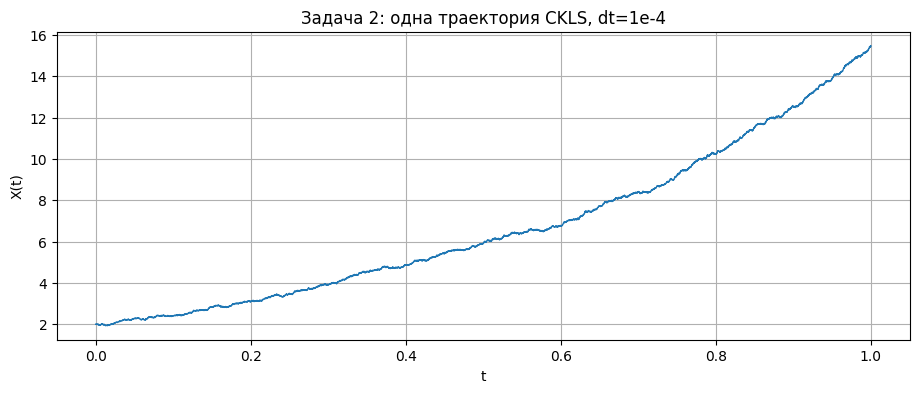

Оценка по одной траектории: [1.05636969 1.86378581 0.49819134 0.30233362]


,parameter,true,mean_estimate,ci_low_95,ci_high_95,bias
0,theta1,1.0,1.063086,0.681904,1.444269,0.063086
1,theta2,2.0,1.988249,1.937360,2.039138,-0.011751
2,theta3,0.5,0.501503,0.498363,0.504643,0.001503
3,theta4,0.3,0.298895,0.295611,0.302178,-0.001105


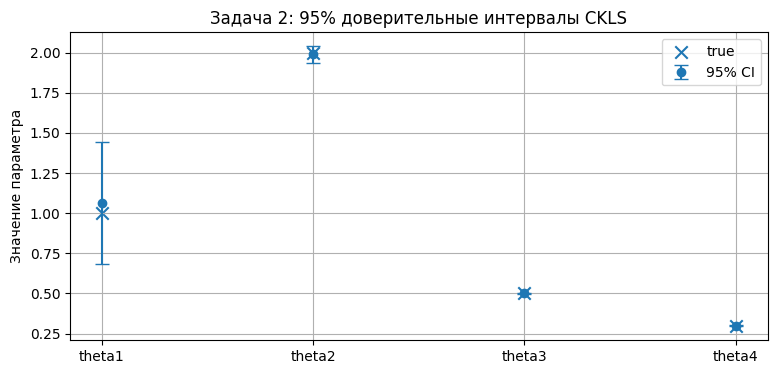

Вывод: метод Эйлера дает практически применимую псевдо-MLE оценку для CKLS при малом шаге.
Параметры сноса могут иметь более широкие интервалы, потому что по одной короткой траектории
информация о drift обычно слабее, чем информация о diffusion.


In [28]:


np.random.seed(43)


def simulate_ckls_euler(theta, T=1.0, dt=1e-4, x0=2.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    theta1, theta2, theta3, theta4 = map(float, theta)
    Nt = int(round(T / dt))
    t = np.linspace(0, T, Nt + 1)
    x = np.zeros(Nt + 1)
    x[0] = x0
    sqrt_dt = np.sqrt(dt)
    for i in range(1, Nt + 1):
        xp = max(x[i - 1], 1e-10)
        x[i] = xp + (theta1 + theta2 * xp) * dt + theta3 * xp ** theta4 * sqrt_dt * rng.normal()
        x[i] = max(x[i], 1e-10)  # чтобы степень x^theta4 была корректна
    return t, x


def ckls_euler_negloglik(theta, x, dt):
    theta1, theta2, theta3, theta4 = theta
    if theta3 <= 0 or theta4 < -2 or theta4 > 3 or not np.isfinite(theta).all():
        return 1e100
    xp = np.maximum(x[:-1], 1e-10)
    xn = x[1:]
    mean = xp + (theta1 + theta2 * xp) * dt
    var = (theta3 ** 2) * (xp ** (2 * theta4)) * dt
    if np.any(var <= 0) or not np.isfinite(var).all():
        return 1e100
    return 0.5 * np.sum(np.log(2 * np.pi * var) + (xn - mean) ** 2 / var)


def estimate_ckls_euler(x, dt, start=np.array([0.5, 1.0, 0.4, 0.2])):
    res = minimize(
        ckls_euler_negloglik,
        x0=start,
        args=(x, dt),
        method='L-BFGS-B',
        bounds=[(-10, 10), (-10, 10), (1e-5, 10), (-1, 2)],
        options={'maxiter': 500},
    )
    return res

params_CKLS_true = np.array([1.0, 2.0, 0.5, 0.3])
T = 1.0
dt = 1e-4
x0 = 2.0
rng = np.random.default_rng(43)

t_ckls, x_ckls = simulate_ckls_euler(params_CKLS_true, T=T, dt=dt, x0=x0, rng=rng)
res_one = estimate_ckls_euler(x_ckls, dt)

plt.figure(figsize=(11, 4))
plt.plot(t_ckls, x_ckls, linewidth=1)
plt.title('Задача 2: одна траектория CKLS, dt=1e-4')
plt.xlabel('t')
plt.ylabel('X(t)')
plt.grid(True)
plt.show()

print('Оценка по одной траектории:', res_one.x)

# Доверительные интервалы по n=50 симуляциям.
n_sim = 50
estimates = np.zeros((n_sim, 4))
start = res_one.x
for k in range(n_sim):
    _, x_sim = simulate_ckls_euler(params_CKLS_true, T=T, dt=dt, x0=x0, rng=rng)
    res = estimate_ckls_euler(x_sim, dt, start=start)
    estimates[k] = res.x
    if res.success:
        start = res.x

alpha = 0.05
q = t.ppf(1 - alpha / 2, n_sim - 1)
means = estimates.mean(axis=0)
stds = estimates.std(axis=0, ddof=1)
half_widths = q * stds / np.sqrt(n_sim)

ci_task2 = pd.DataFrame({
    'parameter': ['theta1', 'theta2', 'theta3', 'theta4'],
    'true': params_CKLS_true,
    'mean_estimate': means,
    'ci_low_95': means - half_widths,
    'ci_high_95': means + half_widths,
    'bias': means - params_CKLS_true,
})
display(ci_task2)

plt.figure(figsize=(9, 4))
plt.errorbar(ci_task2['parameter'], ci_task2['mean_estimate'], yerr=half_widths, fmt='o', capsize=5, label='95% CI')
plt.scatter(ci_task2['parameter'], ci_task2['true'], marker='x', s=80, label='true')
plt.title('Задача 2: 95% доверительные интервалы CKLS')
plt.ylabel('Значение параметра')
plt.grid(True)
plt.legend()
plt.show()

print('Вывод: метод Эйлера дает практически применимую псевдо-MLE оценку для CKLS при малом шаге.')
print('Параметры сноса могут иметь более широкие интервалы, потому что по одной короткой траектории')
print('информация о drift обычно слабее, чем информация о diffusion.')

Задача 3. Локальная линеаризация (Метод Озаки)

1. Для модели Вазичека с фиксированным $\sigma$ реализуйте оценку параметров методом Озаки.
2.  Сравните результаты метода Озаки с методом Эйлера при различных шагах дискретизации $\Delta t \in \{10^{-1}, 10^{-2}, 10^{-3}\}$.
3. Подтвердите теоретический вывод о том, что методы локальной линеаризации работают лучше метода Эйлера при увеличении шага $\Delta t$.
4. Сделайте выводы.

,dt,method,mean_theta1,mean_theta2,bias_theta1,bias_theta2,rmse_theta1,rmse_theta2
0,0.100,Euler,2.711279,2.006867,-0.288721,0.006867,0.447241,0.054786
1,0.100,Ozaki,3.017923,2.005213,0.017923,0.005213,0.384853,0.065324
2,0.010,Euler,2.997808,1.992228,-0.002192,-0.007772,0.454966,0.054952
3,0.010,Ozaki,3.100181,2.006955,0.100181,0.006955,0.381191,0.050540
4,0.001,Euler,3.122585,2.012009,0.122585,0.012009,0.363483,0.052598
5,0.001,Ozaki,3.203869,2.011196,0.203869,0.011196,0.507378,0.048369


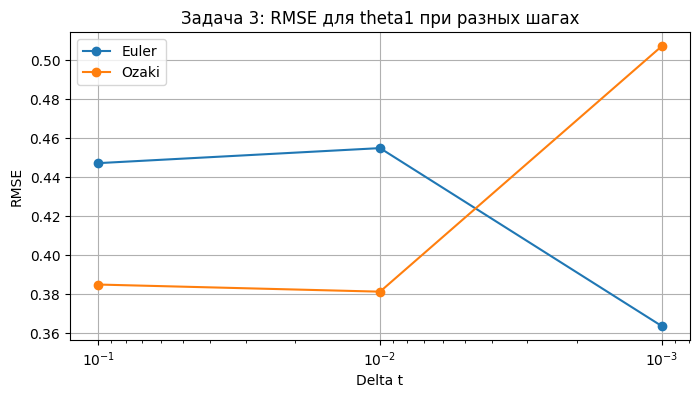

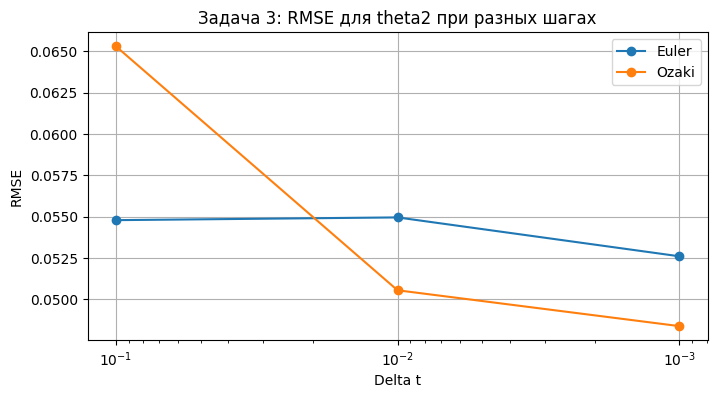

Вывод: для Vasicek метод Озаки использует локально-линейную динамику и фактически совпадает
с точной OU-переходной плотностью. Поэтому при крупном шаге dt=1e-1 он обычно устойчивее
и менее смещен, чем Euler. При уменьшении dt различия между методами сокращаются.


In [29]:

np.random.seed(44)


def vasicek_euler_neglog_fixed_sigma(params, x, dt, sigma_fixed):
    kappa, alpha = params
    if kappa <= 0 or not np.isfinite(params).all():
        return 1e100
    xp, xn = x[:-1], x[1:]
    mean = xp + kappa * (alpha - xp) * dt
    var = sigma_fixed ** 2 * dt
    return 0.5 * np.sum(np.log(2 * np.pi * var) + (xn - mean) ** 2 / var)


def vasicek_ozaki_neglog_fixed_sigma(params, x, dt, sigma_fixed):
    # Для Vasicek локальная линеаризация совпадает с точным OU-переходом.
    kappa, alpha = params
    if kappa <= 0 or not np.isfinite(params).all():
        return 1e100
    xp, xn = x[:-1], x[1:]
    phi = np.exp(-kappa * dt)
    mean = alpha + (xp - alpha) * phi
    var = sigma_fixed ** 2 * (1 - np.exp(-2 * kappa * dt)) / (2 * kappa)
    if var <= 0:
        return 1e100
    return 0.5 * np.sum(np.log(2 * np.pi * var) + (xn - mean) ** 2 / var)


def estimate_vasicek_fixed_sigma(x, dt, sigma_fixed, method='Euler'):
    fun = vasicek_euler_neglog_fixed_sigma if method == 'Euler' else vasicek_ozaki_neglog_fixed_sigma
    start = np.array([1.0, np.mean(x)])
    res = minimize(fun, start, args=(x, dt, sigma_fixed), method='L-BFGS-B', bounds=[(1e-6, 50), (-50, 50)])
    return res.x

params_vas_true = np.array([3.0, 2.0, 0.5])
sigma_fixed = params_vas_true[2]
x0 = 5.0
T = 10.0
dt_grid = [1e-1, 1e-2, 1e-3]
n_rep = 40
rng = np.random.default_rng(44)

rows = []
for dt_i in dt_grid:
    Nt_i = int(round(T / dt_i))
    for method in ['Euler', 'Ozaki']:
        estimates_i = []
        for r in range(n_rep):
            _, x_i = simulate_ou_exact(params_vas_true, T, Nt_i, x0, rng=rng)
            estimates_i.append(estimate_vasicek_fixed_sigma(x_i, dt_i, sigma_fixed, method=method))
        estimates_i = np.asarray(estimates_i)
        rmse = np.sqrt(np.mean((estimates_i - params_vas_true[:2]) ** 2, axis=0))
        bias = np.mean(estimates_i, axis=0) - params_vas_true[:2]
        rows.append({
            'dt': dt_i,
            'method': method,
            'mean_theta1': estimates_i[:, 0].mean(),
            'mean_theta2': estimates_i[:, 1].mean(),
            'bias_theta1': bias[0],
            'bias_theta2': bias[1],
            'rmse_theta1': rmse[0],
            'rmse_theta2': rmse[1],
        })

compare_task3 = pd.DataFrame(rows)
display(compare_task3)

for param in ['theta1', 'theta2']:
    plt.figure(figsize=(8, 4))
    for method in ['Euler', 'Ozaki']:
        tmp = compare_task3[compare_task3['method'] == method]
        plt.plot(tmp['dt'], tmp[f'rmse_{param}'], marker='o', label=method)
    plt.xscale('log')
    plt.gca().invert_xaxis()
    plt.title(f'Задача 3: RMSE для {param} при разных шагах')
    plt.xlabel('Delta t')
    plt.ylabel('RMSE')
    plt.grid(True)
    plt.legend()
    plt.show()

print('Вывод: для Vasicek метод Озаки использует локально-линейную динамику и фактически совпадает')
print('с точной OU-переходной плотностью. Поэтому при крупном шаге dt=1e-1 он обычно устойчивее')
print('и менее смещен, чем Euler. При уменьшении dt различия между методами сокращаются.')

Задача 4. Оценивание моделей с временной зависимостью (Метод Кесслера)

1. Рассмотрите расширенную модель Вазичека (модель Халла-Уайта), где коэффициенты зависят от времени.

2. Используйте метод Кесслера и оцените параметры сноса и диффузии по траектории, сгенерированной с параметрами $(3.0, 1.0, 0.3)$, $\Delta t = 10^{-3}$.

3. Рассчитайте матрицу ковариации оценок параметров.

4. Сделайте выводы.


,parameter,true,Kessler_estimate,abs_error
0,theta1,3.0,2.433487,0.566513
1,theta2,1.0,0.570736,0.429264
2,theta3,0.3,0.310488,0.010488


,theta1,theta2,theta3
theta1,-0.061022,-0.042352,0.000079
theta2,-0.042352,-0.010055,0.000037
theta3,0.000079,0.000037,0.000048


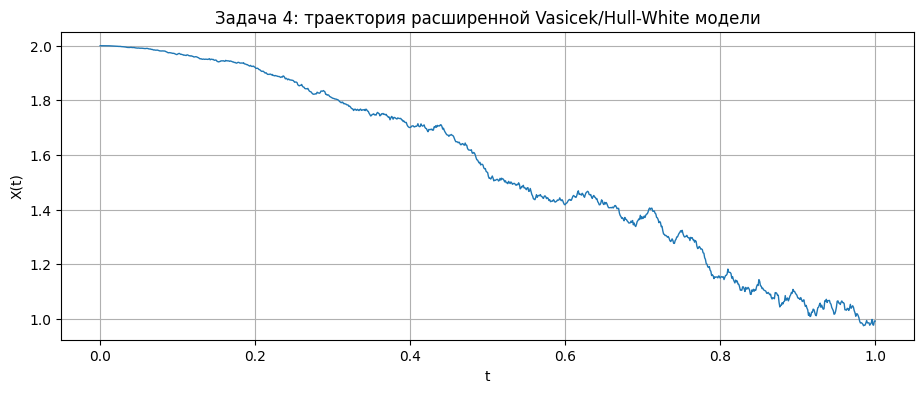

Вывод: метод Кесслера аппроксимирует условные среднее и дисперсию через разложение Ито-Тейлора,
поэтому подходит для моделей с временной зависимостью коэффициентов. Ковариационная матрица
получена как обратная численная матрица Гессе отрицательного лог-правдоподобия в точке оценки.


In [30]:

np.random.seed(45)


def kessler_neglog_hw(theta, t_data, x_data):
    theta = np.asarray(theta, dtype=float)
    if theta[0] <= 0 or theta[2] <= 0 or not np.isfinite(theta).all():
        return 1e100
    params = theta
    total = 0.0
    for i in range(1, len(t_data)):
        t0 = t_data[i - 1]
        t1 = t_data[i]
        dt = t1 - t0
        x0 = x_data[i - 1]
        x1 = x_data[i]
        b = params[0] * t0 * (params[1] * np.sqrt(max(t0, 0.0)) - x0)
        bx = -params[0] * t0
        bxx = 0.0
        sig = params[2] * t0
        sx = 0.0
        sxx = 0.0
        E = x0 + b * dt + (b * bx + 0.5 * sig ** 2 * bxx) * 0.5 * dt ** 2
        V_second_moment = (x0 ** 2 + (2 * b * x0 + sig ** 2) * dt +
                           (2 * b * (bx * x0 + b + sig * sx) + sig ** 2 *
                            (bxx * x0 + 2 * bx + sx ** 2 + sig * sxx)) * dt ** 2 / 2)
        V = V_second_moment - E ** 2
        V = max(V, 1e-10)
        total += 0.5 * (np.log(2 * np.pi * V) + (x1 - E) ** 2 / V)
    return total


def simulate_hw_euler(theta, T=1.0, dt=1e-3, x0=2.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    Nt = int(round(T / dt))
    t = np.linspace(0, T, Nt + 1)
    x = np.zeros(Nt + 1)
    x[0] = x0
    for i in range(1, Nt + 1):
        tp = t[i - 1]
        b = theta[0] * tp * (theta[1] * np.sqrt(tp) - x[i - 1])
        sig = theta[2] * tp
        x[i] = x[i - 1] + b * dt + sig * np.sqrt(dt) * rng.normal()
    return t, x


def numerical_hessian(fun, x0, rel_step=1e-4):
    x0 = np.asarray(x0, dtype=float)
    p = len(x0)
    H = np.zeros((p, p))
    steps = rel_step * np.maximum(np.abs(x0), 1.0)
    f0 = fun(x0)
    for i in range(p):
        ei = np.zeros(p); ei[i] = steps[i]
        f_plus = fun(x0 + ei)
        f_minus = fun(x0 - ei)
        H[i, i] = (f_plus - 2 * f0 + f_minus) / steps[i] ** 2
        for j in range(i + 1, p):
            ej = np.zeros(p); ej[j] = steps[j]
            fpp = fun(x0 + ei + ej)
            fpm = fun(x0 + ei - ej)
            fmp = fun(x0 - ei + ej)
            fmm = fun(x0 - ei - ej)
            H[i, j] = H[j, i] = (fpp - fpm - fmp + fmm) / (4 * steps[i] * steps[j])
    return H

params_hw_true = np.array([3.0, 1.0, 0.3])
T = 1.0
dt = 1e-3
x0 = 2.0
rng = np.random.default_rng(45)
t_hw, x_hw = simulate_hw_euler(params_hw_true, T=T, dt=dt, x0=x0, rng=rng)

res_hw = minimize(
    kessler_neglog_hw,
    x0=np.array([2.0, 0.8, 0.2]),
    args=(t_hw, x_hw),
    method='L-BFGS-B',
    bounds=[(1e-5, 20), (-10, 10), (1e-5, 5)],
    options={'maxiter': 1000},
)
hat_hw = res_hw.x

H = numerical_hessian(lambda th: kessler_neglog_hw(th, t_hw, x_hw), hat_hw)
try:
    cov_hw = np.linalg.inv(H)
except np.linalg.LinAlgError:
    cov_hw = np.linalg.pinv(H)

summary_task4 = pd.DataFrame({
    'parameter': ['theta1', 'theta2', 'theta3'],
    'true': params_hw_true,
    'Kessler_estimate': hat_hw,
    'abs_error': np.abs(hat_hw - params_hw_true),
})
display(summary_task4)

display(pd.DataFrame(cov_hw, index=['theta1', 'theta2', 'theta3'], columns=['theta1', 'theta2', 'theta3']))

plt.figure(figsize=(11, 4))
plt.plot(t_hw, x_hw, linewidth=1)
plt.title('Задача 4: траектория расширенной Vasicek/Hull-White модели')
plt.xlabel('t')
plt.ylabel('X(t)')
plt.grid(True)
plt.show()

print('Вывод: метод Кесслера аппроксимирует условные среднее и дисперсию через разложение Ито-Тейлора,')
print('поэтому подходит для моделей с временной зависимостью коэффициентов. Ковариационная матрица')
print('получена как обратная численная матрица Гессе отрицательного лог-правдоподобия в точке оценки.')

Задача 5. Исследование схем наблюдений

1. Проведите эксперимент, сравнивающий точность оценок в зависимости от дизайна эксперимента:
*   Large sample scheme: $\Delta=const$, увеличивающееся $n$ (общее время $T \to \infty$).
*   High-frequency scheme: Фиксированное $T=const$, уменьшающийся шаг $\Delta \to 0$.
2. Установите, как меняется смещение (bias) и дисперсия оценок параметров сноса и диффузии при переходе от одной схемы к другой. Подкрепите выводы иллюстративными графиками.

3. Сделайте выводы.

,scheme,n,Delta,T,parameter,bias,variance
0,Large sample,100,0.100000,10.0,theta1/kappa,0.557303,0.737838
1,Large sample,100,0.100000,10.0,theta2/alpha,0.009937,0.019303
2,Large sample,100,0.100000,10.0,theta3/sigma,0.005331,0.003125
3,Large sample,300,0.100000,30.0,theta1/kappa,0.131433,0.112500
4,Large sample,300,0.100000,30.0,theta2/alpha,-0.010155,0.006978
5,Large sample,300,0.100000,30.0,theta3/sigma,-0.001144,0.000844
6,Large sample,1000,0.100000,100.0,theta1/kappa,0.037095,0.034878
7,Large sample,1000,0.100000,100.0,theta2/alpha,-0.002316,0.002078
8,Large sample,1000,0.100000,100.0,theta3/sigma,0.002448,0.000305
9,Large sample,3000,0.100000,300.0,theta1/kappa,-0.001568,0.010111


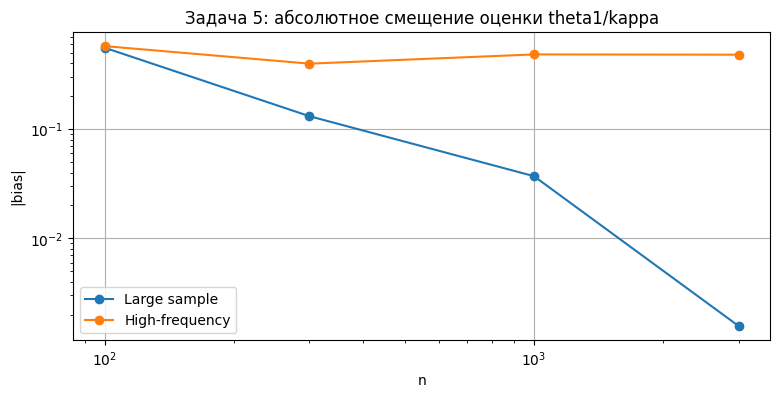

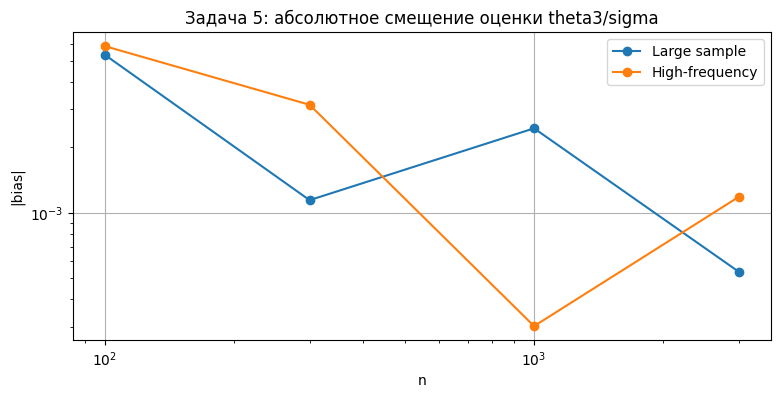

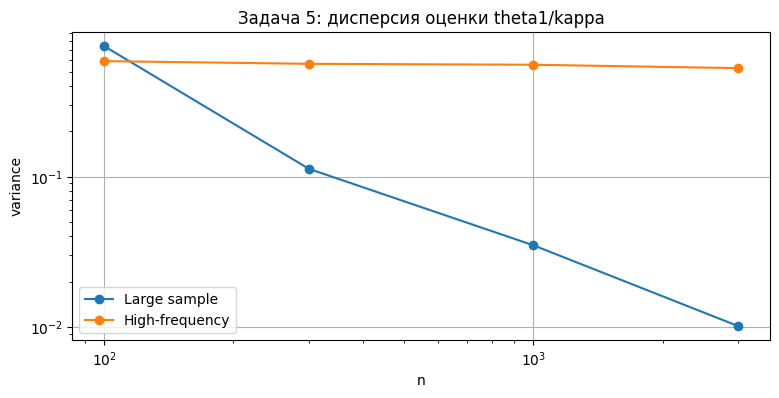

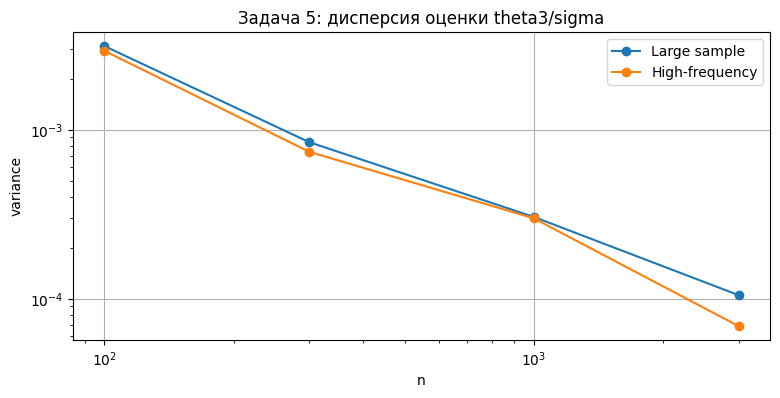

Вывод: в large sample растет горизонт T, поэтому улучшается оценивание параметров сноса
(theta1, theta2): траектория дольше исследует стационарное распределение. В high-frequency
при фиксированном T уточняется дискретизация, поэтому особенно хорошо оценивается диффузия theta3,
но информация о drift ограничена конечным временным окном.


In [31]:

np.random.seed(46)

true_theta = np.array([1.5, 2.0, 0.7])
x0 = 2.0
rng = np.random.default_rng(46)
M = 120

# Large sample: Delta фиксирован, n растет, T=n*Delta растет.
large_delta = 0.1
large_n_grid = [100, 300, 1000, 3000]

# High-frequency: T фиксирован, Delta=T/n уменьшается.
hf_T = 10.0
hf_n_grid = [100, 300, 1000, 3000]

rows = []
for n_obs in large_n_grid:
    estimates = []
    T_i = n_obs * large_delta
    for m in range(M):
        _, x_i = simulate_ou_exact(true_theta, T_i, n_obs, x0, rng=rng)
        estimates.append(ou_exact_mle(x_i, large_delta))
    estimates = np.asarray(estimates)
    for idx, pname in enumerate(['theta1/kappa', 'theta2/alpha', 'theta3/sigma']):
        rows.append({
            'scheme': 'Large sample',
            'n': n_obs,
            'Delta': large_delta,
            'T': T_i,
            'parameter': pname,
            'bias': estimates[:, idx].mean() - true_theta[idx],
            'variance': estimates[:, idx].var(ddof=1),
        })

for n_obs in hf_n_grid:
    estimates = []
    dt_i = hf_T / n_obs
    for m in range(M):
        _, x_i = simulate_ou_exact(true_theta, hf_T, n_obs, x0, rng=rng)
        estimates.append(ou_exact_mle(x_i, dt_i))
    estimates = np.asarray(estimates)
    for idx, pname in enumerate(['theta1/kappa', 'theta2/alpha', 'theta3/sigma']):
        rows.append({
            'scheme': 'High-frequency',
            'n': n_obs,
            'Delta': dt_i,
            'T': hf_T,
            'parameter': pname,
            'bias': estimates[:, idx].mean() - true_theta[idx],
            'variance': estimates[:, idx].var(ddof=1),
        })

design_task5 = pd.DataFrame(rows)
display(design_task5)

for pname in ['theta1/kappa', 'theta3/sigma']:
    plt.figure(figsize=(9, 4))
    for scheme in ['Large sample', 'High-frequency']:
        tmp = design_task5[(design_task5['parameter'] == pname) & (design_task5['scheme'] == scheme)]
        plt.plot(tmp['n'], np.abs(tmp['bias']), marker='o', label=scheme)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Задача 5: абсолютное смещение оценки {pname}')
    plt.xlabel('n')
    plt.ylabel('|bias|')
    plt.grid(True)
    plt.legend()
    plt.show()

for pname in ['theta1/kappa', 'theta3/sigma']:
    plt.figure(figsize=(9, 4))
    for scheme in ['Large sample', 'High-frequency']:
        tmp = design_task5[(design_task5['parameter'] == pname) & (design_task5['scheme'] == scheme)]
        plt.plot(tmp['n'], tmp['variance'], marker='o', label=scheme)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Задача 5: дисперсия оценки {pname}')
    plt.xlabel('n')
    plt.ylabel('variance')
    plt.grid(True)
    plt.legend()
    plt.show()

print('Вывод: в large sample растет горизонт T, поэтому улучшается оценивание параметров сноса')
print('(theta1, theta2): траектория дольше исследует стационарное распределение. В high-frequency')
print('при фиксированном T уточняется дискретизация, поэтому особенно хорошо оценивается диффузия theta3,')
print('но информация о drift ограничена конечным временным окном.')